In [1]:
from utils.load_dataset import load_lsst_data
import matplotlib.pyplot as plt
import numpy as np

# Set a clean style for the plots
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
X_train, y_train, X_test, y_test = load_lsst_data()

Loading LSST dataset...


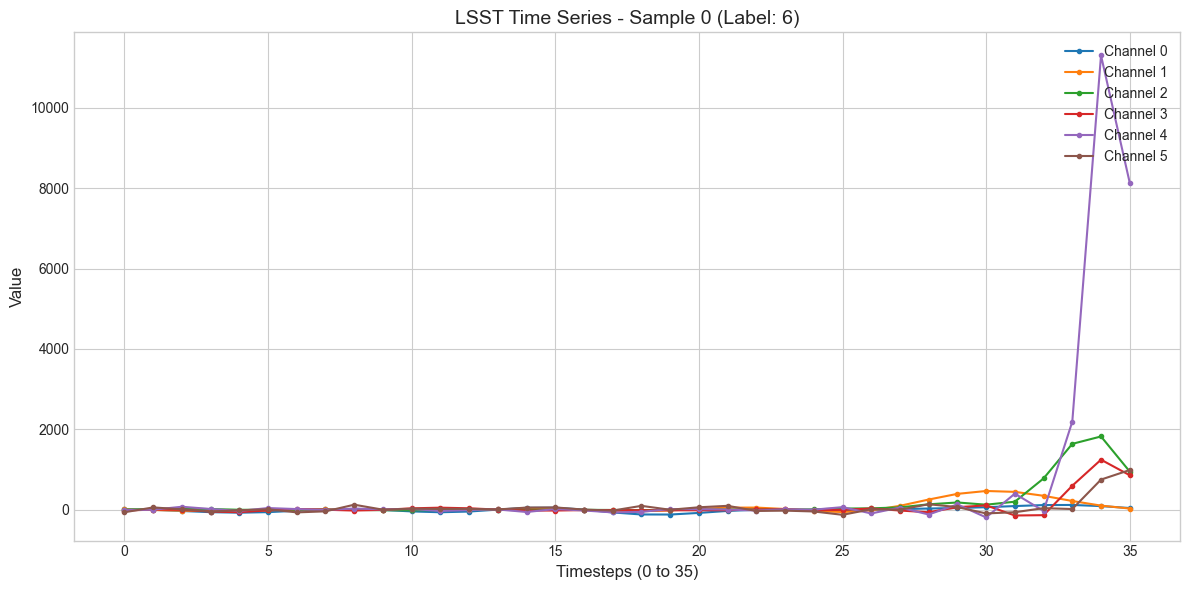

In [ ]:
sample_idx = 0
sample = X_train[sample_idx]
sample_label = y_train[sample_idx]

plt.figure(figsize=(12, 6))

# Loop through each of the 6 channels and plot them
for channel_idx in range(sample.shape[0]):
    plt.plot(sample[channel_idx, :], marker='.', label=f"Channel {channel_idx}")

plt.title(f"LSST Time Series - Sample {sample_idx} (Label: {sample_label})", fontsize=14)
plt.xlabel("Timesteps (0 to 35)", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

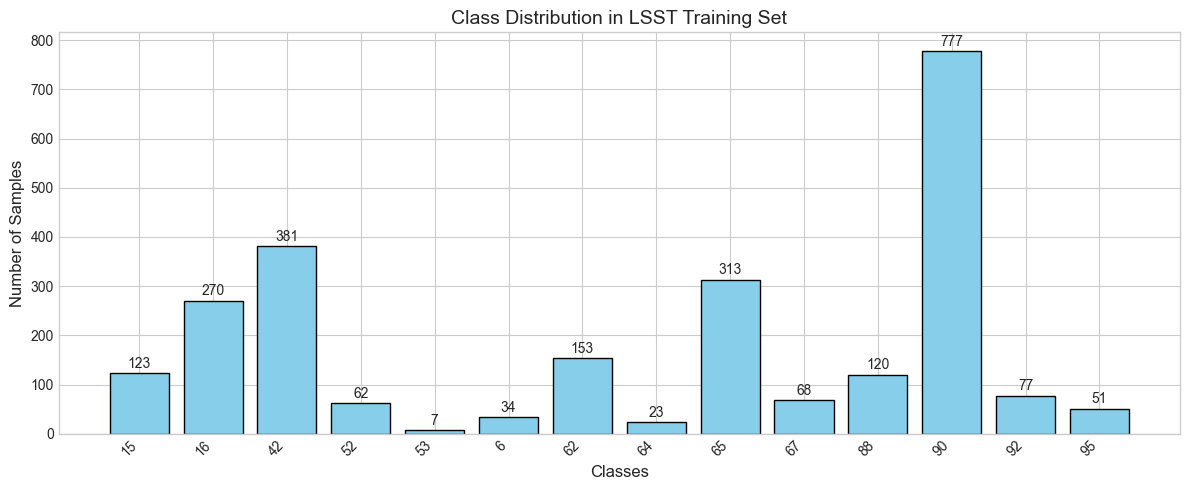

In [ ]:
# Get unique classes and their frequencies
unique_classes, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(12, 5))
bars = plt.bar(unique_classes.astype(str), counts, color='skyblue', edgecolor='black')

plt.title("Class Distribution in LSST Training Set", fontsize=14)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add the specific count above each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

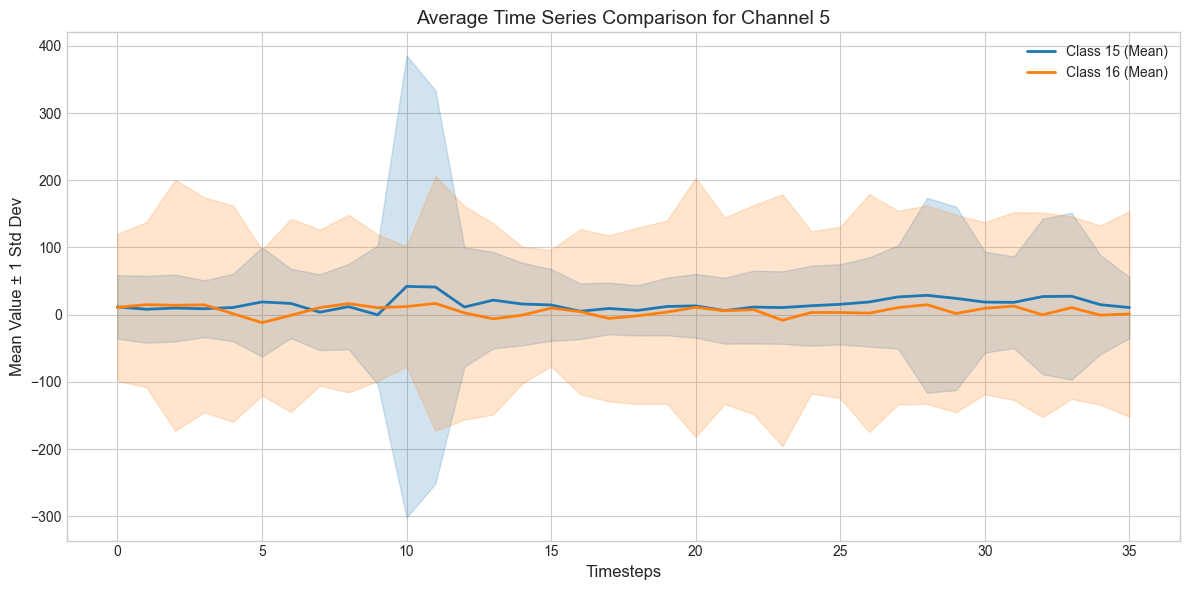

In [9]:
target_channel = 5 # Looking at the first channel
classes_to_compare = unique_classes[:2] # Grab the first two distinct classes to compare

plt.figure(figsize=(12, 6))

for cls in classes_to_compare:
    # Filter the dataset for the specific class
    class_mask = (y_train == cls)
    class_samples = X_train[class_mask]
    
    # Calculate the mean across all samples for the target channel
    mean_series = np.mean(class_samples[:, target_channel, :], axis=0)
    std_series = np.std(class_samples[:, target_channel, :], axis=0)
    
    # Plot mean and fill the standard deviation area
    timesteps = np.arange(mean_series.shape[0])
    line = plt.plot(timesteps, mean_series, label=f"Class {cls} (Mean)", linewidth=2)
    plt.fill_between(timesteps, mean_series - std_series, mean_series + std_series, alpha=0.2, color=line[0].get_color())

plt.title(f"Average Time Series Comparison for Channel {target_channel}", fontsize=14)
plt.xlabel("Timesteps", fontsize=12)
plt.ylabel("Mean Value ± 1 Std Dev", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()